In [91]:
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt 
import numpy as np

In [92]:
df = pd.read_csv("../data/covid_toy.csv")

In [93]:
df.sample(5)

,age,gender,fever,cough,city,has_covid
48,66,Male,99.0,Strong,Bangalore,No
10,75,Female,NaN,Mild,Delhi,No
5,84,Female,NaN,Mild,Bangalore,Yes
56,71,Male,NaN,Strong,Kolkata,No
84,69,Female,98.0,Strong,Mumbai,No


In [94]:
df_categorical = df.drop(columns=["age", "fever"])
df_numerical = df[["age", "fever"]]

In [95]:
df_numerical.sample(5)

,age,fever
67,65,99.0
6,14,101.0
68,54,104.0
57,49,99.0
8,19,100.0


In [96]:
# Applying Standard Scalar on numerical features

In [97]:
# Train-test split

from sklearn.model_selection import train_test_split

X = df_numerical
y = df["has_covid"] #Or -- df.iloc[:, -1]  # Assuming the last column is the target variable

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42) 

In [98]:
X_train.shape

(70, 2)

In [99]:
X_test.shape

(30, 2)

In [100]:
from sklearn.preprocessing import StandardScaler

scalar = StandardScaler()

In [101]:
scalar.fit(X_train)

StandardScaler()

In [102]:
scalar.mean_

array([ 41.58571429, 100.96721311])

In [103]:
X_train_scaled = scalar.transform(X_train)
X_test_scaled = scalar.transform(X_test)

In [104]:
X_train_scaled

array([[ 0.98336969, -1.38019231],
       [-0.99056947,  1.4106938 ],
       [-1.07456688,  0.94554611],
       [-1.07456688,  1.4106938 ],
       [-0.61258112, -0.44989694],
       [ 1.7813451 ,         nan],
       [ 0.39538781,  1.4106938 ],
       [ 1.15136452,  0.48039843],
       [ 1.69734769,  0.48039843],
       [ 1.15136452,  0.94554611],
       [ 0.10139687,  1.4106938 ],
       [ 1.36135804,  0.48039843],
       [-0.90657206,         nan],
       [-1.2425617 ,  1.4106938 ],
       [-0.36058889,  0.48039843],
       [ 0.01739946,         nan],
       [ 0.98336969, -0.91504462],
       [-0.78057594,         nan],
       [ 0.60538134,  1.4106938 ],
       [ 0.94137099,  0.48039843],
       [-1.200563  , -0.44989694],
       [-0.4445863 , -1.38019231],
       [-0.06659795, -1.38019231],
       [ 0.3113904 ,  0.01525074],
       [-0.94857077, -0.44989694],
       [-1.28456041, -0.44989694],
       [-1.15856429,  0.01525074],
       [ 0.01739946,  1.4106938 ],
       [-0.15059536,

In [105]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=df_numerical.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=df_numerical.columns)

In [106]:
X_train_scaled

,age,fever
0,0.983370,-1.380192
1,-0.990569,1.410694
2,-1.074567,0.945546
3,-1.074567,1.410694
4,-0.612581,-0.449897
...,...,...
65,-0.738577,0.480398
66,1.403357,1.410694
67,0.395388,1.410694
68,1.697348,0.480398


In [107]:
np.round(X_train_scaled.describe(), 1)

#Mean = 0, std = 1 ---- data has been scaled by standard scaling

,age,fever
count,70.0,61.0
mean,-0.0,-0.0
std,1.0,1.0
min,-1.5,-1.4
25%,-0.9,-0.9
50%,-0.0,0.0
75%,1.0,0.9
max,1.8,1.4


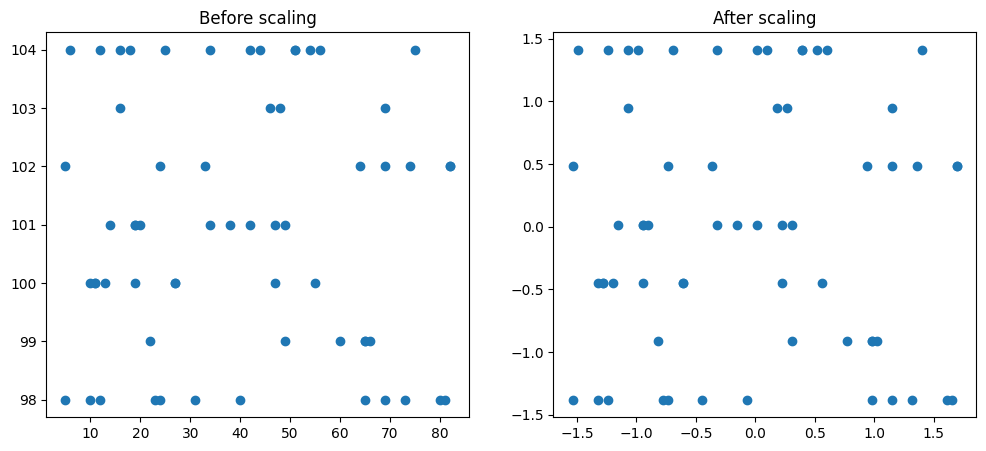

In [108]:
# Understanding the effect of standard scaling 

fig, (ax1, ax2) = plt.subplots(ncols = 2, figsize = (12, 5))

ax1.scatter(X_train["age"], X_train["fever"])
ax1.set_title("Before scaling")
ax2.scatter(X_train_scaled["age"], X_train_scaled["fever"])
ax2.set_title("After scaling")
plt.show()

#Data-distribution doesnt change, only values are scaled to have mean = 0 and std = 1.
#This is important for ML algorithms that are sensitive to the scale of data, such as SVM, KNN, and gradient descent-based algorithms.
#Mean-centering and scaling to standard deviation of 1 takes place in standard scaling. 

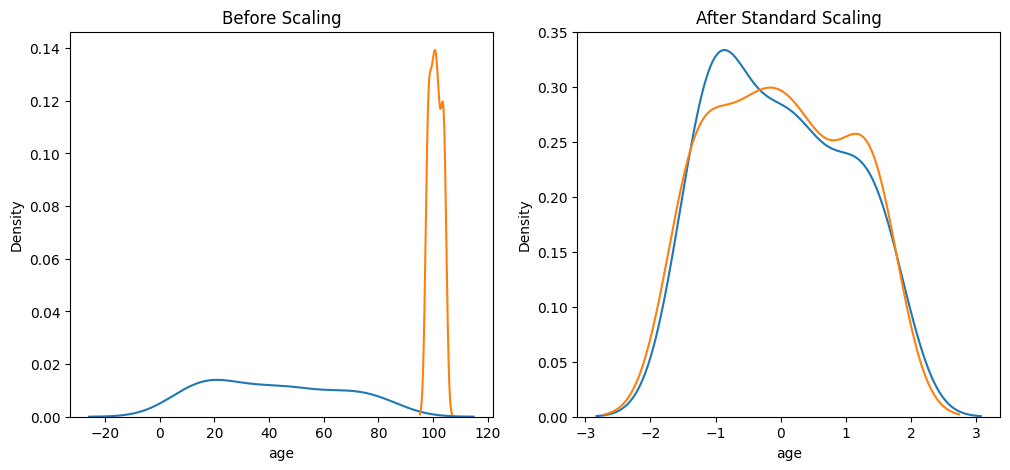

In [109]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(X_train['age'], ax=ax1)
sns.kdeplot(X_train['fever'], ax=ax1)

# after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(X_train_scaled['age'], ax=ax2)
sns.kdeplot(X_train_scaled['fever'], ax=ax2)
plt.show()

#It becomes easier to compare features on the same scale, which can improve the performance of machine learning algorithms.

In [110]:
#Standardization is helpful in algos like linear regression, logistic regression, gradient-descent and neural networks
#There is no need to standardize categorical features, as they are not affected by the scale of the data.
#There is also no need to standardize in algos like decision trees, random forests, and gradient boosting, as they are not sensitive to the scale of the data.